In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [14]:
# =========================
# Load data
# =========================
# Load dataset to start preprocessing and feature engineering

df = pd.read_csv("/content/clean_data (1).csv")

In [15]:
# =========================
# One-Hot Encoding
# =========================
# Convert text columns to numbers for ML models
# drop_first removes duplicate information

df = pd.get_dummies(df, columns=["Neighborhood", "MS Zoning"], drop_first=True)

In [16]:
# =========================
# Fix data type
# =========================
# Convert to int because values are ordered (1 to 10)
# This keeps the ranking meaning for the model

df["Overall Qual"] = df["Overall Qual"].astype(int)

In [17]:
# =========================
# Train / Test Split
# =========================
# Split data to evaluate model on unseen data
# 80% training, 20% testing

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [18]:
# =========================
# Feature Scaling
# =========================
# Standardize numeric columns so all features are on same scale
# Fit only on training data to avoid data leakage

scaler = StandardScaler()
num_cols = ["Lot Area", "Gr Liv Area"]

# fit on training only
train_df[num_cols] = scaler.fit_transform(train_df[num_cols])

# apply on test
test_df[num_cols] = scaler.transform(test_df[num_cols])
df = train_df

In [19]:
# =========================
# Feature Engineering
# =========================
# We create new features to give the model more useful information
# Instead of using raw columns, we build meaningful relationships between them
# Ratio feature

# Price per square foot
# Shows how expensive the house is relative to its size
df["price_per_sqft"] = df["SalePrice"] / df["Gr Liv Area"].replace(0, 1)

# Total bathrooms
# Combines full and half bathrooms into one clearer feature
df["total_bathrooms"] = df["Full Bath"] + (0.5 * df["Half Bath"])

# Age at sale
# More useful than year built because it directly shows how old the house is
df["age_at_sale"] = df["Yr Sold"] - df["Year Built"]

In [20]:
# Combine two important features into one

df["quality_x_area"] = df["Overall Qual"] * df["Gr Liv Area"]

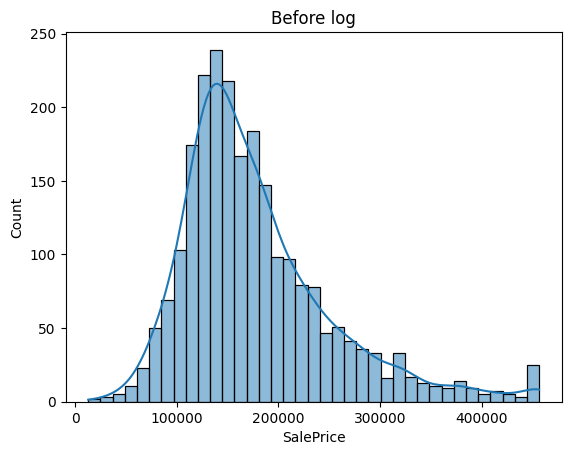

In [21]:
# Before log transformation
# Show distribution of house prices to see skewness

sns.histplot(df["SalePrice"], kde=True)
plt.title("Before log")
plt.show()

In [22]:
# Apply log transformation
# Reduce skewness in price distribution for better model performance

df["SalePrice_log"] = np.log1p(df["SalePrice"])

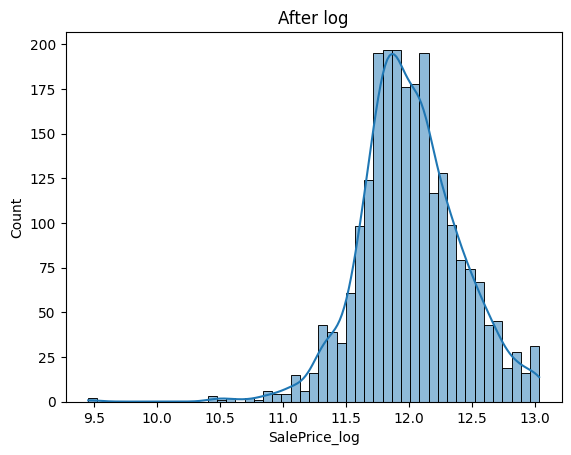

In [23]:
# After log transformation
# Check if price distribution became more normal

sns.histplot(df["SalePrice_log"], kde=True)
plt.title("After log")
plt.show()

In [24]:
# Age groups
# Convert age into categories to simplify patterns for the model

df["age_group"] = pd.cut(
    df["age_at_sale"],
    bins=[0, 10, 30, 100],
    labels=["New", "Recent", "Old"])

In [25]:
# Correlation matrix
# Measures relationships between numeric features

corr = df.corr(numeric_only=True)


In [26]:
# Drop highly correlated feature
# Remove redundant column to reduce duplication and noise
df = df.drop(columns=["Garage Cars"])

In [27]:
df.to_csv("features_DataSet.csv", index=False)